In [2]:
############################################################
# INSTALAR LIBRERÍAS
############################################################

!pip install squarify
!pip install plotly
!pip install scipy
!pip install scikit-bio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 58.5 MB/s eta 0:00:00


In [3]:
############################################################
# IMPORTAR LIBRERÍAS
############################################################

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

import squarify

from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import pdist

from sklearn.preprocessing import StandardScaler

from skbio.diversity import beta_diversity

############################################################
# CONFIGURACIÓN
############################################################

plt.rcParams["figure.figsize"] = (12,8)

sns.set_style("whitegrid")

In [4]:
############################################################
# LEER ARCHIVOS
############################################################

abundance = pd.read_csv(
    "abundance_matrix.csv"
)

relative = pd.read_csv(
    "relative_abundance.csv"
)

alpha = pd.read_csv(
    "alpha_diversity.csv"
)

metadata = pd.read_csv(
    "metadata.csv"
)

############################################################
# VISUALIZAR
############################################################

abundance.head()

,Taxon,JC1A,JP4D
0,Paracoccus pantotrophus,678,1219
1,Bradyrhizobium sp. SK17,1450,0
2,Bradyrhizobium sp. A19,11,0
3,Bradyrhizobium betae,300,0
4,Phyllobacterium sp. T1293,39,0


🟢 NIVEL 1 — VISUALIZACIÓN
🧬 1. STACKED BARPLOT
🎯 OBJETIVO

Visualizar composición taxonómica.

Permite detectar:

✅ taxones dominantes
✅ enriquecimiento ecológico
✅ diferencias ambientales

In [5]:
############################################################
# TOP 15 TAXONES
############################################################

abundance["Total"] = (
    abundance["JC1A"] +
    abundance["JP4D"]
)

top15 = abundance.sort_values(
    by="Total",
    ascending=False
).head(15)

############################################################
# FORMATO LARGO
############################################################

top15_long = pd.melt(
    top15,
    id_vars=["Taxon"],
    value_vars=["JC1A", "JP4D"],
    var_name="Sample",
    value_name="Abundance"
)

############################################################
# ABUNDANCIA RELATIVA
############################################################

top15_long["Relative"] = (
    top15_long.groupby("Sample")
    ["Abundance"]
    .transform(lambda x: x/x.sum()*100)
)

############################################################
# GRAFICAR
############################################################

fig = px.bar(
    top15_long,

    x="Sample",
    y="Relative",

    color="Taxon",

    title="Composición Taxonómica",

    labels={
        "Relative":"Abundancia Relativa (%)"
    }
)

fig.show()

🧬 2. HEATMAP AVANZADO
🎯 OBJETIVO

Visualizar patrones taxonómicos.

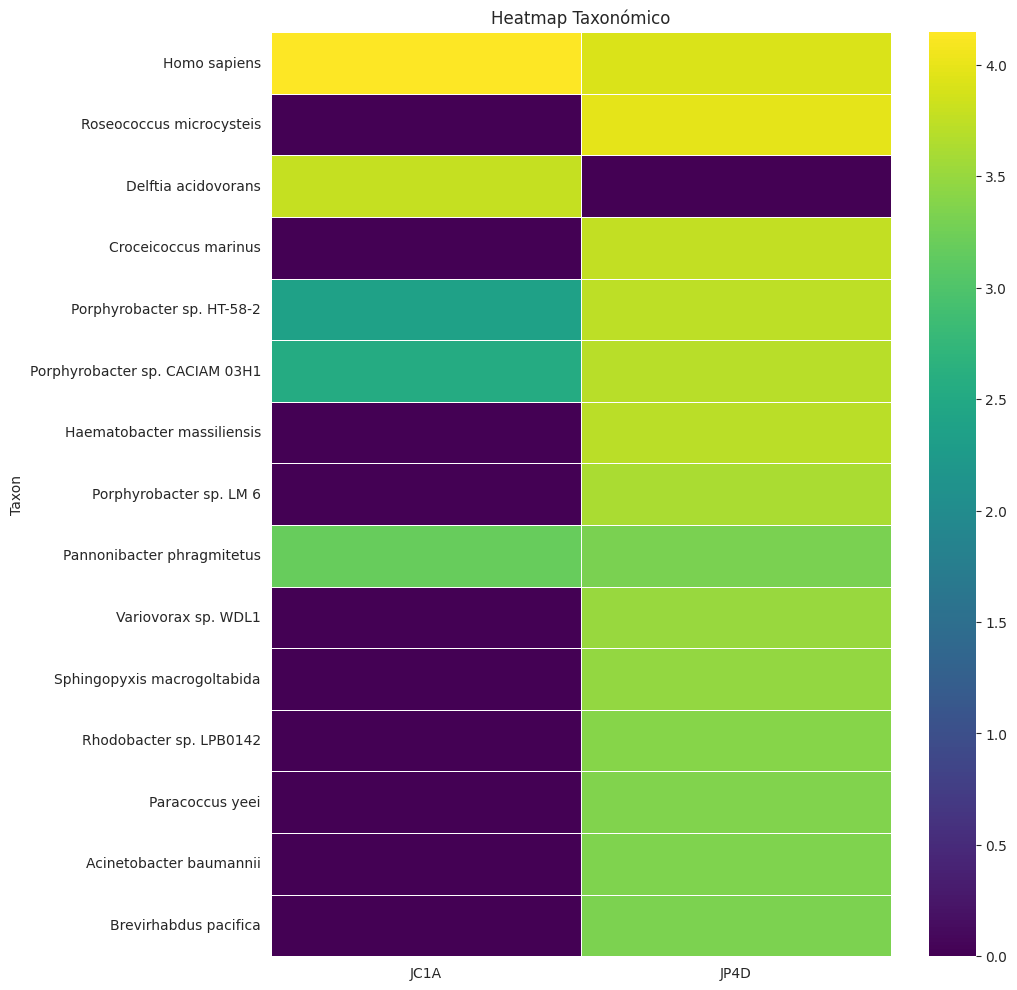

In [6]:
############################################################
# PREPARAR MATRIZ
############################################################

heatmap_data = top15.set_index(
    "Taxon"
)[["JC1A", "JP4D"]]

############################################################
# LOG TRANSFORMACIÓN
############################################################

heatmap_data = np.log10(
    heatmap_data + 1
)

############################################################
# HEATMAP
############################################################

plt.figure(figsize=(10,12))

sns.heatmap(
    heatmap_data,

    cmap="viridis",

    linewidths=0.5
)

plt.title(
    "Heatmap Taxonómico"
)

plt.show()

🧬 3. BUBBLE PLOT
🎯 OBJETIVO

Comparar abundancias.

In [7]:
############################################################
# BUBBLE PLOT
############################################################

fig = px.scatter(
    top15_long,

    x="Sample",
    y="Taxon",

    size="Relative",
    color="Relative",

    title="Distribución Taxonómica"
)

fig.show()

🧬 4. TREEMAP
🎯 OBJETIVO

Mostrar dominancia taxonómica.

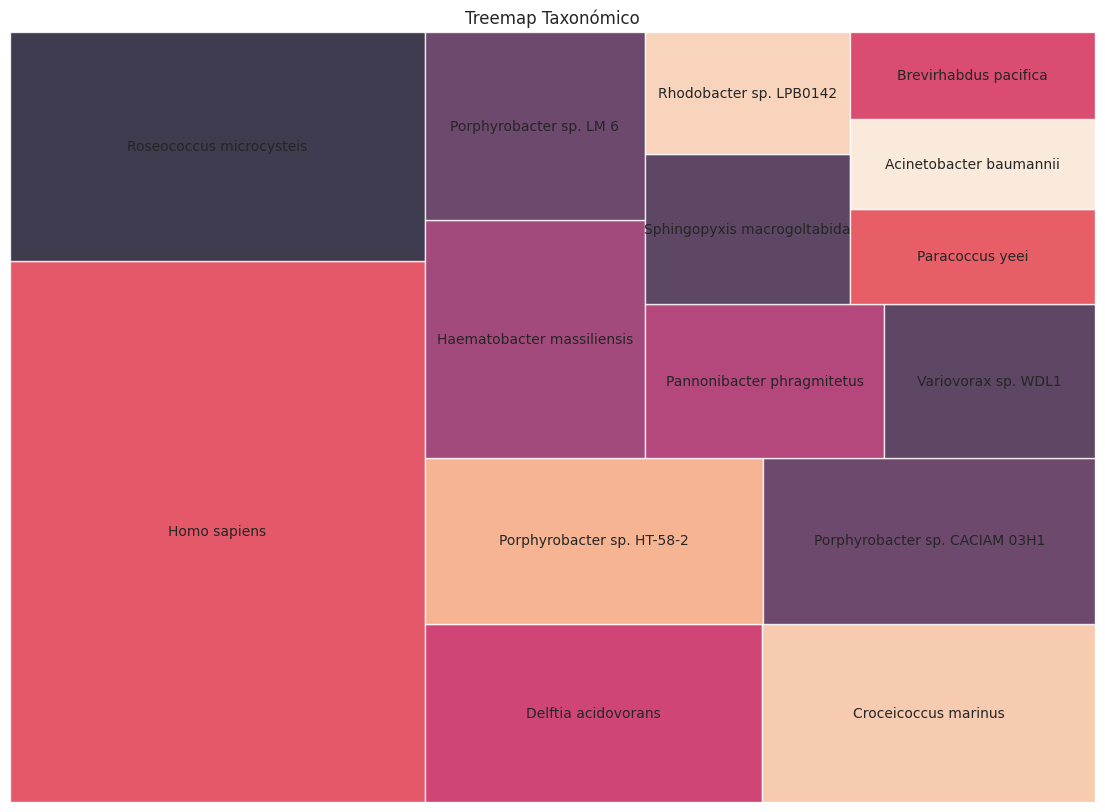

In [8]:
############################################################
# TREEMAP
############################################################

plt.figure(figsize=(14,10))

squarify.plot(

    sizes=top15["Total"],

    label=top15["Taxon"],

    alpha=0.8
)

plt.axis("off")

plt.title(
    "Treemap Taxonómico"
)

plt.show()

🔵 NIVEL 2 — INTERACTIVO

🧬 5. SANKEY DIAGRAM
🎯 OBJETIVO

Relacionar:

muestra,
taxón,
abundancia.

In [9]:
############################################################
# NODOS
############################################################

labels = (
    list(top15_long["Sample"].unique()) +
    list(top15_long["Taxon"].unique())
)

############################################################
# MAPEO
############################################################

label_to_index = {
    label:i for i,label in enumerate(labels)
}

############################################################
# LINKS
############################################################

source = [
    label_to_index[s]
    for s in top15_long["Sample"]
]

target = [
    label_to_index[t]
    for t in top15_long["Taxon"]
]

value = list(
    top15_long["Relative"]
)

############################################################
# SANKEY
############################################################

fig = go.Figure(
    data=[
        go.Sankey(

            node=dict(
                label=labels
            ),

            link=dict(
                source=source,
                target=target,
                value=value
            )
        )
    ]
)

fig.update_layout(
    title_text="Sankey Taxonómico",
    font_size=12
)

fig.show()

SUNBURST PLOT
🎯 OBJETIVO

Jerarquía ecológica.

In [10]:
############################################################
# SUNBURST
############################################################

fig = px.sunburst(

    top15_long,

    path=["Sample", "Taxon"],

    values="Relative",

    title="Sunburst Taxonómico"
)

fig.show()


7. DASHBOARD PLOTLY
🎯 OBJETIVO

Visualización interactiva.

In [11]:
############################################################
# DASHBOARD SIMPLE
############################################################

fig = px.bar(
    top15_long,

    x="Taxon",
    y="Relative",

    color="Sample",

    barmode="group",

    title="Dashboard Taxonómico"
)

fig.show()

🟣 NIVEL 3 — ECOLÓGICO

🧬 8. CLUSTERING
🎯 OBJETIVO

Agrupar taxones similares.

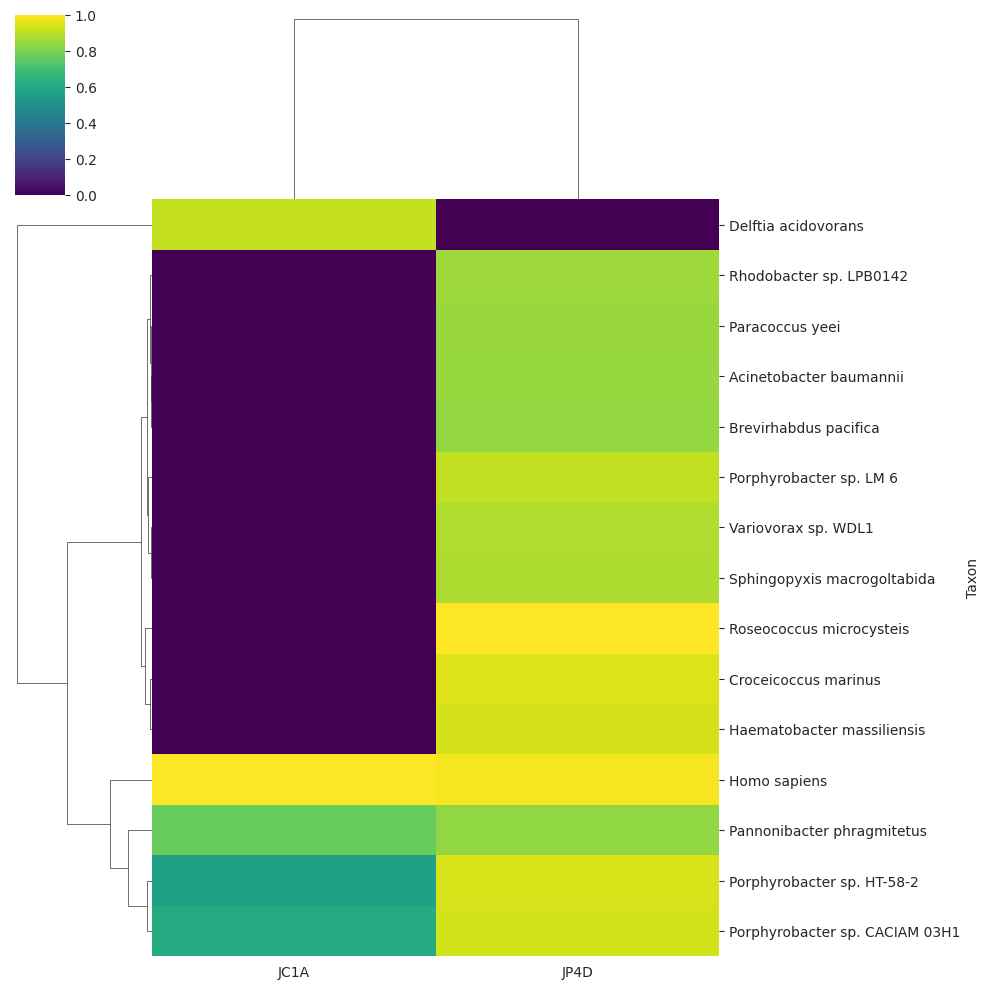

In [12]:
############################################################
# MATRIZ
############################################################

cluster_data = heatmap_data

############################################################
# CLUSTERMAP
############################################################

sns.clustermap(

    cluster_data,

    cmap="viridis",

    standard_scale=1
)

plt.show()

🧬 9. BRAY-CURTIS
🎯 OBJETIVO

Comparar composición ecológica.

In [13]:
############################################################
# MATRIZ
############################################################

counts = abundance.set_index(
    "Taxon"
)[["JC1A", "JP4D"]].T

############################################################
# BRAY-CURTIS
############################################################

bc = beta_diversity(

    metric="braycurtis",

    counts=counts.values,

    ids=counts.index
)

print(bc)

2x2 distance matrix
IDs:
'JC1A', 'JP4D'
Data:
[[0.         0.81081035]
 [0.81081035 0.        ]]


10. COMPOSITIONAL ANALYSIS
🎯 OBJETIVO

Comparar proporciones ecológicas.

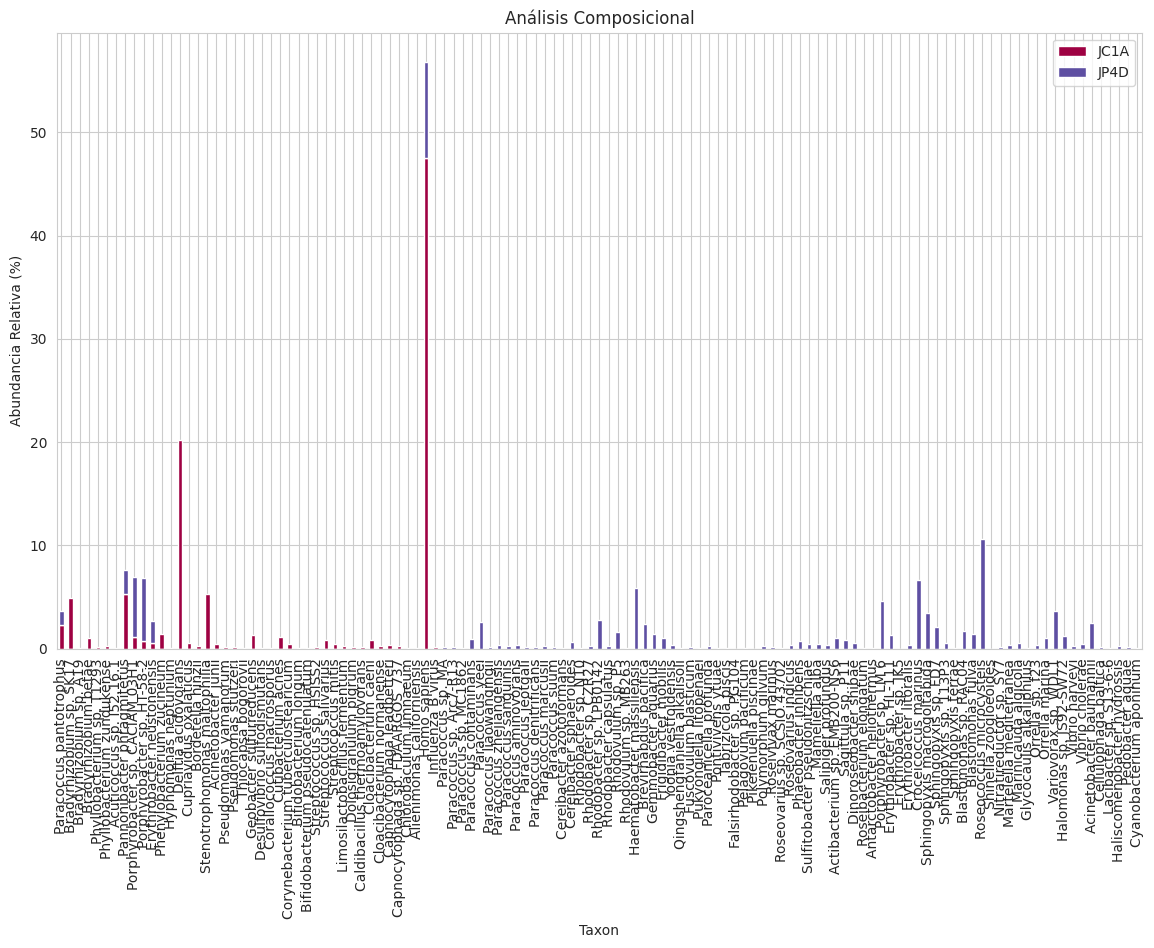

In [14]:
############################################################
# ABUNDANCIA RELATIVA
############################################################

relative_data = (
    counts.div(
        counts.sum(axis=1),
        axis=0
    ) * 100
)

############################################################
# STACKED COMPOSITIONAL
############################################################

relative_data.T.plot(

    kind="bar",

    stacked=True,

    figsize=(14,8),

    colormap="Spectral"
)

plt.ylabel(
    "Abundancia Relativa (%)"
)

plt.title(
    "Análisis Composicional"
)

plt.show()